In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Documents\OneDrive\Desktop\Data_Science notes\Phase2_dl\Day1\HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Define features (X) and target (y)
X = df[['satisfaction_level']]
y = df['left']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [4]:
# Initialize and train a new Logistic Regression model for the HR data
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
X_test

,satisfaction_level
6723,0.65
6473,0.88
4679,0.69
862,0.41
7286,0.87
...,...
3297,0.61
14113,0.93
5514,0.78
9939,0.89


In [6]:
y_predicted = model.predict(X_test)

In [7]:
model.predict_proba(X_test)

array([[0.82026037, 0.17973963],
       [0.91738999, 0.08261001],
       [0.84194499, 0.15805501],
       ...,
       [0.88295898, 0.11704102],
       [0.92027333, 0.07972667],
       [0.55070285, 0.44929715]], shape=(3000, 2))

In [8]:
model.score(X_test,y_test)

0.7546666666666667

In [9]:
y_predicted

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

In [10]:
X_test

,satisfaction_level
6723,0.65
6473,0.88
4679,0.69
862,0.41
7286,0.87
...,...
3297,0.61
14113,0.93
5514,0.78
9939,0.89


In [11]:
model.coef_

array([[-3.86647528]])

In [12]:
model.intercept_

array([0.99509642])

In [13]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [14]:
def predict_hr(satisfaction_level):
    # Use the coefficients and intercept from the trained HR model (model_hr)
    z = model.coef_[0][0] * satisfaction_level + model.intercept_[0]
    y = sigmoid(z)
    return y

In [15]:
sat_level = 0.45
predict_hr(sat_level)

0.321951598109027

In [16]:
sat_level = 0.85
predict_hr(sat_level)

0.0918370868224578

c:\Users\dhanu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


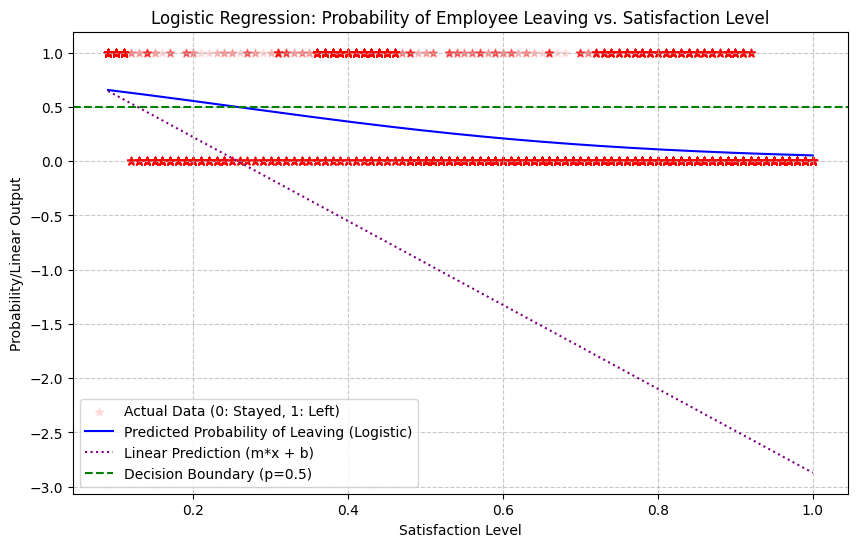

In [19]:
# Generate a range of satisfaction levels for plotting the logistic curve
satis_plot = np.linspace(df['satisfaction_level'].min(), df['satisfaction_level'].max(), 300).reshape(-1, 1)

# Predict probabilities for these satisfaction levels using the HR model
probability= model.predict_proba(satis_plot)[:, 1] # Get probability of class 1 (left the company)

plt.figure(figsize=(10, 6))

# Plot the original data points (jittered for better visualization if many points overlap)
plt.scatter(df.satisfaction_level, df.left, marker='*', color='red', label='Actual Data (0: Stayed, 1: Left)', alpha=0.1)

# Plot the logistic regression curve
plt.plot(satis_plot, probability, color='blue', label='Predicted Probability of Leaving (Logistic)')

# Calculate the linear part of the logistic function (m*x + b)
linear_predict = model.coef_[0][0] * satis_plot + model.intercept_[0]
plt.plot(satis_plot, linear_predict, color='purple', linestyle=':', label='Linear Prediction (m*x + b)')

# Add a horizontal line for the decision boundary (p=0.5)
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision Boundary (p=0.5)')

plt.title('Logistic Regression: Probability of Employee Leaving vs. Satisfaction Level')
plt.xlabel('Satisfaction Level')
plt.ylabel('Probability/Linear Output')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()